In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 12,           
    "axes.titlesize": 14,      
    "axes.labelsize": 12,     
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

In [ ]:
def prepare_data(data):
    all_keys = data.files
    X = []
    y = []
    for key in all_keys:
        genre = key.split("/")[0]
        X.append(data[key])
        y.append(genre)
    return X,y
X,y = prepare_data(data)
print(len(y))

In [ ]:
from tqdm import tqdm
import torch
target_time = 1020
def get_embeddings(X, y, layer = -1):
    spectrograms = {}
    target_time = 1020
    for i in tqdm(range(len(y))):
        spec = X[i]
        label = y[i]
        # if spec.shape[0] > target_time:
        #     spec = spec[:target_time, :]
        if spec.shape[0] > target_time:
            start = (spec.shape[0] - target_time) // 2
            spec = spec[start: start + target_time, :]
        elif  spec.shape[0] < target_time:
            pad = target_time - spec.shape[0]
            spec = np.pad(spec, ((0, pad), (0, 0)), mode="constant")
        spec = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)
        try:
            with torch.no_grad():
                patches = model.ast.embeddings(spec)
                encoder_outputs = model.ast.encoder(patches, output_hidden_states=True)
                hidden_states = encoder_outputs.hidden_states  
                #using pre-last layer 
                pre_last = hidden_states[layer]            
                embedding = pre_last.mean(dim=1) 
                spectrograms[label] = embedding
        except Exception as e:
            print(f"problem with the file {lst[i]}")
            print(e)
    return spectrograms


## correlation

In [ ]:
import ast
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
def to_float(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, float)): return float(x)
    return float(x.split(" ")[0])
def  get_acc_sil_correlation(df, metric = "Accuracy", score = "Silhouette"):
    df = df.applymap(to_float)
    acc = df.xs(metric, level="Metric", axis=1).values.flatten()
    sil = df.xs(score, level="Metric", axis=1).values.flatten()
    mask = ~np.isnan(acc) & ~np.isnan(sil)
    acc, sil = acc[mask], sil[mask]

    pearson, _  = pearsonr(acc, sil)
    spearman, _ = spearmanr(acc, sil)
    return float("%.3f"% pearson), float("%.3f" % spearman)

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import re

_num = re.compile(r"\s*([+-]?\d+(?:\.\d+)?)")

def to_float(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, float, np.floating)): return float(x)
    m = _num.match(str(x))
    return float(m.group(1)) if m else np.nan

def get_acc_sil_correlation(df, metric="Accuracy", score="Silhouette"):
    if ("Reduction", "Metric") in df.columns:
        df = df.set_index(("Reduction", "Metric"))

    if not isinstance(df.columns, pd.MultiIndex) or df.columns.nlevels != 2:
        raise ValueError("Expected 2-level MultiIndex columns (Reduction × Metric).")
    if "Metric" not in (df.columns.names or []):
        df.columns = df.columns.set_names(["Reduction", "Metric"])

    df_num = df.applymap(to_float)

    acc = df_num.xs(metric, level="Metric", axis=1).to_numpy().ravel()
    sil = df_num.xs(score,  level="Metric", axis=1).to_numpy().ravel()

    mask = np.isfinite(acc) & np.isfinite(sil)
    pearson, _  = pearsonr(acc[mask], sil[mask])
    spearman, _ = spearmanr(acc[mask], sil[mask])
    return round(pearson, 3), round(spearman, 3)

In [ ]:
import pandas as pd
import warnings
import os
warnings.simplefilter("ignore", category=FutureWarning)

scores = [ "CH"]
spearman_correlation = {score : {} for score in scores}
pearson_correlation= {score : {} for score in scores}
pearsons = {}
spearmans = {}
base_path = "clustering_results/full"
for i in range (1, 13):
    layer = -i
    mean_std_df = pd.read_csv(os.path.join(base_path, f"df_layer{layer}_mean_std_more_metrics.csv"), header = [0,1])
    mean_std_df  = mean_std_df .set_index(("Reduction", "Metric"))
    mean_std_df  = mean_std_df[:5] 
    
    for score in scores:

        pearson, spearman = get_acc_sil_correlation(mean_std_df, score = score)
        spearman_correlation[score][13-i] = - spearman if score == "DB" else spearman
        pearson_correlation[score][13-i] = - pearson if score == "DB" else pearson


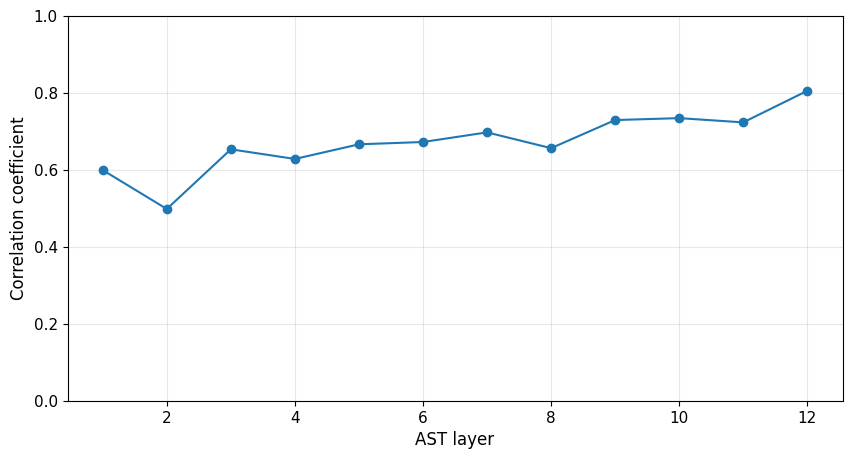

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,5))
for score in scores:
    values_spearman = spearman_correlation[score]
    values_pearson = pearson_correlation[score]
    if score == "CH":
        label = "Calinski-Harabasz"
    elif score == "DB":
        label = "Davies-Bouldin (negative)"
    else:
        label = score
    ax.plot(values_spearman.keys(), values_spearman.values(),marker="o", label = "Spearman")
ax.set_xlabel("AST layer")
ax.set_ylabel("Correlation coefficient")
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)
plt.savefig("figures/layers_correlation_ch_grid_spearman.pdf")
plt.show()


## hyperparameter analysis

In [ ]:
def get_clustering_dict_layer(root_path, layer, num_iter= None, clustering = "hdbscan"):
    iter = "_10" if num_iter else ""
    path = os.path.join(root_path, f"df_layer{layer}_mean_std_more_metrics{iter}.csv")
    df = pd.read_csv(path,  header=[0, 1], index_col=0)
    clustering_df = df[df.index.str.contains(clustering, case=False)]
    columns = clustering_df .columns.values
    all_dr = set([col[0] for col in columns])
    all_algs = clustering_df [("None", "Accuracy")].index
    result = {alg: [] for alg in all_algs}
    for dr in all_dr:
        dr_res =  clustering_df [(dr, "Accuracy")].to_dict()

        for key in result:
            value = dr_res[key]
            value = float(str(value).split(" ")[0])  
            result[key].append(value)
    return result


In [151]:
def get_red_dict_layer(root_path, layer, dim_red):
    dr_result = {}
    path = os.path.join(root_path, f"df_layer{layer}_mean_std_more_metrics_10_renamed.csv")
    df = pd.read_csv(path,  header=[0, 1], index_col=0)
    all_dr = set([col[0] for col in columns if dim_red  in col[0].lower()])
    for dr in all_dr:
        total_values = df[(dr, "Accuracy")].values
        total_values = [float(value.split(" ")[0]) for value in total_values]
        values = [total_values[0],np.mean(total_values[1:5]), np.mean(total_values[5:29]), max(total_values[29:53])]
        dr_result[dr] = values

    return dr_result

#### pca


In [ ]:
root_path = ""
pca_result = get_red_dict_layer(root_path, layer = -100, dim_red= "pca")


for i in range (1,13):
    layer = -i
    result_layer =get_red_dict_layer(root_path, layer,dim_red= "pca" )
    pca_result = {key: pca_result[key] + result_layer[key] for key in pca_result.keys()}

C:\Users\polin\AppData\Local\Temp\ipykernel_42480\626328921.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


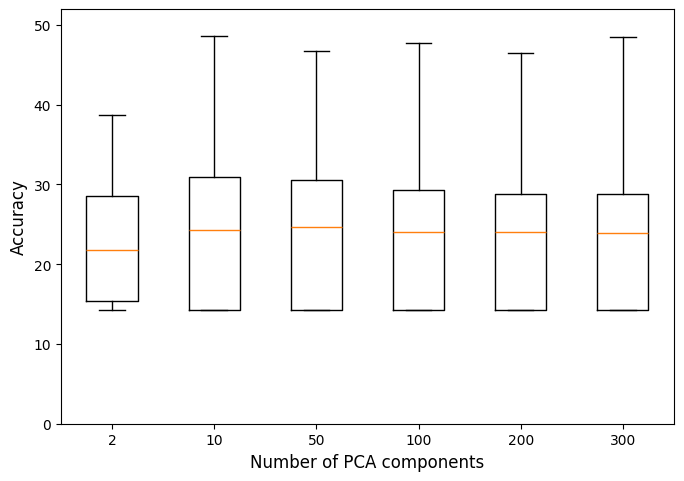

In [ ]:
import re
import matplotlib.pyplot as plt

keys_sorted = sorted(
    pca_result.keys(),
    key=lambda k: int(re.search(r"comp(\d+)", k).group(1))
)

data = [pca_result[k] for k in keys_sorted]

labels = [re.search(r"comp(\d+)", k).group(1) for k in keys_sorted]

plt.figure(figsize=(7,5))
plt.boxplot(data, labels=labels)

plt.xlabel("Number of PCA components")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.ylim(0,52)
plt.savefig("/figures/pca_boxes.pdf")
plt.show()


#### umap

In [ ]:
root_path = ""
umap_result = get_red_dict_layer(root_path, layer = -100, dim_red= "umap")
for i in range (1,13):
    layer = -i
    result_layer =get_red_dict_layer(root_path, layer,dim_red= "umap" )
    umap_result  = {key: umap_result [key] + result_layer[key] for key in umap_result.keys()}

C:\Users\polin\AppData\Local\Temp\ipykernel_42480\331313154.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_ngh, labels=nghs)
C:\Users\polin\AppData\Local\Temp\ipykernel_42480\331313154.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_comp, labels=comps)


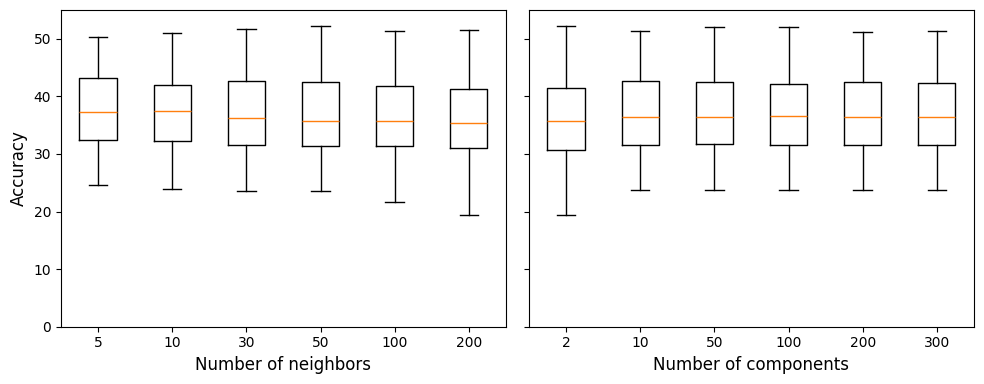

In [ ]:
import re
by_ngh = {}
by_comp = {}

for k, vals in umap_result.items():

    ngh = int(re.search(r"ngh(\d+)", k).group(1))
    comp = int(re.search(r"comp(\d+)", k).group(1))

    by_ngh.setdefault(ngh, []).extend(vals)
    by_comp.setdefault(comp, []).extend(vals)
nghs = sorted(by_ngh.keys())
comps = sorted(by_comp.keys())

data_ngh  = [by_ngh[n] for n in nghs]
data_comp = [by_comp[c] for c in comps]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].boxplot(data_ngh, labels=nghs)
axes[0].set_xlabel("Number of neighbors")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 55)

axes[1].boxplot(data_comp, labels=comps)
axes[1].set_xlabel("Number of components")

plt.tight_layout()
plt.savefig("figures/umap_boxes.pdf")
plt.show()


#### t-sne

In [ ]:
root_path = ""
tsne_result = get_red_dict_layer(root_path, layer = -100, dim_red= "t-sne")
for i in range (1,13):
    layer = -i
    result_layer =get_red_dict_layer(root_path, layer,dim_red= "t-sne" )
    tsne_result = {key: tsne_result[key] + result_layer[key] for key in tsne_result.keys()}

C:\Users\polin\AppData\Local\Temp\ipykernel_42480\3879674802.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=comps)


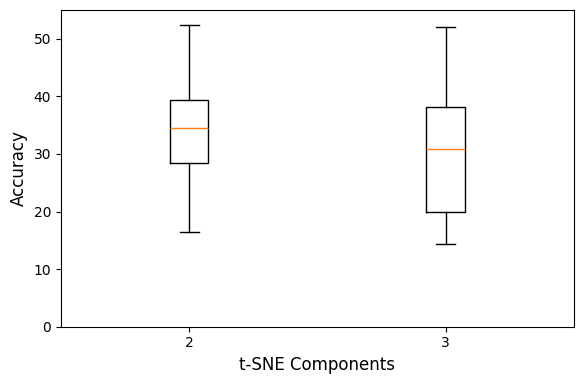

In [ ]:
grouped = {}
for k, vals in tsne_result.items():
    comp = int(re.search(r"comp(\d+)", k).group(1))
    grouped.setdefault(comp, []).extend(vals)

comps = sorted(grouped.keys())
data = [grouped[c] for c in comps]

plt.figure(figsize=(6,4))
plt.ylim(0,55)
plt.boxplot(data, labels=comps)

plt.xlabel("t-SNE Components")
plt.ylabel("Accuracy")
plt.savefig("figures/tsne_components_boxes.pdf")
plt.tight_layout()
plt.show()

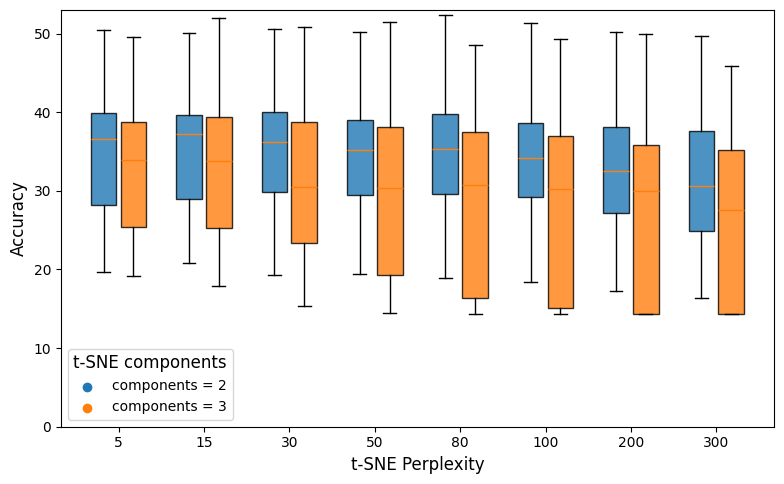

In [ ]:
grouped = {}
components_set = set()

for k, vals in tsne_result.items():
    p = int(re.search(r"p(\d+)", k).group(1))
    comp = int(re.search(r"comp(\d+)", k).group(1))
    
    grouped.setdefault(p, {})
    grouped[p].setdefault(comp, [])
    grouped[p][comp].extend(vals)
    components_set.add(comp)

perps = sorted(grouped.keys())
components = sorted(components_set)

color_map = {
    components[i]: c
    for i, c in enumerate(["tab:blue", "tab:orange"])
}

plt.figure(figsize=(8,5))

width = 0.35
positions = []
data = []
colors = []

x_base = range(1, len(perps)+1)

for i, p in enumerate(perps):
    comps_here = sorted(grouped[p].keys())

    shifts = [-width/2, width/2, width]  
    
    for shift, comp in zip(shifts, comps_here):
        positions.append(x_base[i] + shift)
        data.append(grouped[p][comp])
        colors.append(color_map[comp])

bp = plt.boxplot(data, positions=positions, widths=0.3, patch_artist=True)

for box, c in zip(bp["boxes"], colors):
    box.set(facecolor=c, alpha=0.8)

plt.xticks(x_base, perps)
plt.xlabel("t-SNE Perplexity")
plt.ylabel("Accuracy")

for comp in components:
    plt.scatter([], [], color=color_map[comp], label=f"components = {comp}")
plt.legend(title="t-SNE components")
plt.ylim(0,53)
plt.savefig("figures/tsne_components_boxes_perplexity.pdf")
plt.tight_layout()
plt.show()

#### agglomerative

In [ ]:
root_path = ""
agg_result= get_clustering_dict_layer(root_path, -100,  clustering = "Agglomerative", num_iter = True)
root = ""

for i in range (1,13):
    layer = -i 
    result_layer =get_clustering_dict_layer(root, layer, num_iter= None, clustering = "Agglomerative")
    agg_result = {key: agg_result[key] + result_layer[key] for key in agg_result.keys()}

C:\Users\polin\AppData\Local\Temp\ipykernel_42480\3291250454.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


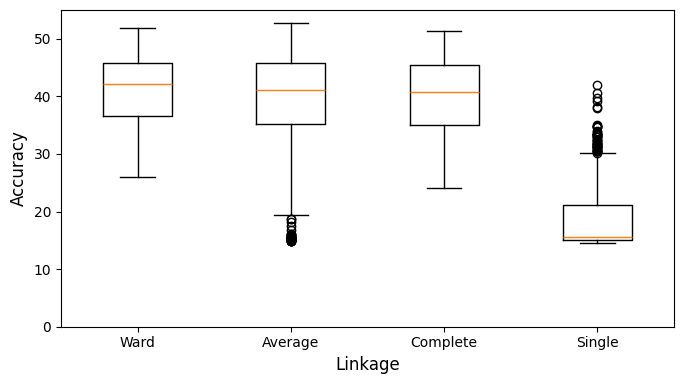

In [ ]:
import matplotlib.pyplot as plt

order = [
    "Agglomerative_ward",
    "Agglomerative_average",
    "Agglomerative_complete",
    "Agglomerative_single",
]

data = [agg_result[k] for k in order]

labels = [k.split("_", 1)[1].capitalize() for k in order]

plt.figure(figsize=(7, 4))
plt.boxplot(data, labels=labels)
plt.ylim(0, 55)
plt.xlabel("Linkage")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig("/figures/agglomerative_boxes.pdf")
plt.show()


#### hdbscan

In [ ]:
root_path = ""
def get_hdbscan_dict_layer(root_path, layer, num_iter= None, clustering = "hdbscan"):
    iter = "_10" if num_iter else ""
    path = os.path.join(root_path, f"df_layer{layer}_mean_std_more_metrics{iter}.csv")
    df = pd.read_csv(path,  header=[0, 1], index_col=0)
    clustering_df = df[df.index.str.contains(clustering, case=False)]
    columns = clustering_df .columns.values
    all_dr = set([col[0] for col in columns])
    all_algs = clustering_df [("None", "Accuracy")].index
    result = {alg: [] for alg in all_algs}
    for dr in all_dr:
        dr_res =  clustering_df [(dr, "Accuracy")].to_dict()
        for key in result:
            value = dr_res[key]
            value = float(str(value).split(" ")[0]) 
            result[key].append(value)
    
    return result

In [ ]:
#centroids
root_path = ""
result = get_hdbscan_dict_layer(root_path,-100, num_iter= True)
result = {key.replace(" (centroids)", "") : result[key] for key in result.keys() }

root = ""

for i in range (1,13):
    layer = -i 
    result_layer = get_hdbscan_dict_layer(root, layer)
    result = {key: result[key] + result_layer[key] for key in result.keys()}

767

In [ ]:
result_eom = {key : value for key ,value in result.items() if "eom" in key}
result_leaf = {key : value for key ,value in result.items() if "leaf" in key}

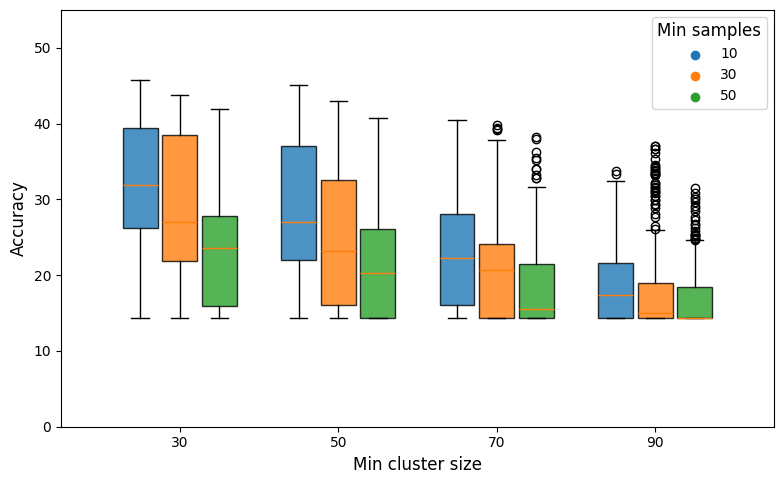

In [ ]:
import re
import pandas as pd
rows = []
for key, values in result_eom.items():
    m = re.search(r"min(\d+)_smpl(\d+)", key)
    if not m:
        continue
        
    min_size = int(m.group(1))
    samples = int(m.group(2))

    for acc in values:
        rows.append({
            "min_size": min_size,
            "samples": samples,
            "accuracy": float(acc)
        })

df = pd.DataFrame(rows)

mins  = sorted(df["min_size"].unique())
smpls = sorted(df["samples"].unique())

colors = {
    smpls[0]: "tab:blue",
    smpls[1]: "tab:orange",
    smpls[2]: "tab:green"
}

plt.figure(figsize=(8,5))

width = 0.25     # spacing of boxplots in a group
positions_shift = [-width, 0, width]

for shift, s in zip(positions_shift, smpls):
    data = [df[(df["min_size"] == m) & (df["samples"] == s)]["accuracy"].values
            for m in mins]

    pos = [i + shift for i in range(1, len(mins)+1)]

    bp = plt.boxplot(
        data,
        positions=pos,
        widths=0.22,
        patch_artist=True
    )

    for patch in bp["boxes"]:
        patch.set(facecolor=colors[s], alpha=0.8)

plt.xticks(range(1, len(mins)+1), mins)
plt.xlabel("Min cluster size")
plt.ylabel("Accuracy")

for s in smpls:
    plt.scatter([], [], color=colors[s], label=f"{s}")

plt.legend(title="Min samples")
plt.ylim(0, 55)
plt.tight_layout()
plt.savefig("/figures/hdbscan_boxes_eom_new_cluster.pdf")
plt.show()


## different layers

In [ ]:
import re
import pandas as pd
import numpy as np

def _parse_cell(x):
    """
    Parse strings like:
      '43.11 + - 2.01'
      '50.34 + - 4.82 (umap_ngh5_dist0_comp100)'
    -> (mean, std, tag) or None
    """
    if pd.isna(x):
        return None
    s = str(x)
    #m = re.search(r'(-?\d+(?:\.\d+)?)\\s*±\s*-\s*(-?\d+(?:\.\d+)?)', s)
    m = re.search(r"\s*([+-]?\d+(?:\.\d+)?)\s*±\s*([+-]?\d+(?:\.\d+)?)", s)
    if not m:
        return None
    mean, std = float(m.group(1)), float(m.group(2))
    tag = None
    m2 = re.search(r'\(([^)]+)\)', s)
    if m2:
        tag = m2.group(1)
    return mean, std, tag

def _family(name):
    n = str(name).lower()
    if n.startswith("kmeans"):
        return "Kmeans"
    if n.startswith("agglomerative"):
        return "Agglomerative"
    if n.startswith("hdbscan"):
        return "HDBSCAN"
    return str(name)



In [ ]:
import warnings
warnings.simplefilter("ignore", category=FutureWarning)
def get_best_results_by_algorithm(df):
    layer_dict = {}
    for index, row in df.iterrows():
        alg = row[0]
        if alg == "KMeans":
            alg = "K-means"
        if alg == "Best reduction (name)":
            break
        mean_best = 0
        std_best = 0
        tag_best = 0
        for i in range(1, len(row)):
            try:
            
                mean, std, tag = _parse_cell(row[i])
                if mean > mean_best:
                    mean_best, std_best = mean, std
                    tag_best = tag
            except Exception as e:
                continue
        layer_dict[alg] = {
            "row" : alg,
            "mean" : mean_best,
            "std": std_best,
            "hyperparams" : tag_best
        }
    return layer_dict

In [ ]:
def load_dict(path, rename= None):
    df = pd.read_csv(os.path.join(path , f"df_layer{layer}_best_results_10.csv"))
    layer_dict = get_best_results_by_algorithm(df)
    if rename:
        for key, value in rename.items():
            layer_dict[value] = layer_dict.pop(key)
    return layer_dict

In [ ]:
import pandas as pd
import os
best_results = {}
best_red_hdbscan = []
best_red_k = []
best_red_a = []
for i in range (1, 13):
    layer = -i 
    results_path = ""
    df = pd.read_csv(os.path.join(results_path, f"df_layer{layer}_best_results.csv"))
    layer_dict = get_best_results_by_algorithm(df)
    layer_dict["HDBSCAN-centroids"] = layer_dict.pop("HDBSCAN")
    layer_dict["HDBSCAN-new"] = layer_dict.pop("old HDBSCAN")
    best_results[13-i] = layer_dict


In [ ]:
# getting raw data
import pandas as pd
import os
best_red_hdbscan = []
best_red_k = []
best_red_a = []
layer = -100
layer_dict_wohdbscan = load_dict(path = "")
layer_dict_hdbscan_centroids = load_dict( "", rename = {"HDBSCAN": "HDBSCAN-centroids"})
layer_dict_hdbscan_normal = load_dict( "", rename = {"old HDBSCAN": "HDBSCAN-new"})
best_results[0] = {**layer_dict_wohdbscan, **layer_dict_hdbscan_centroids, **layer_dict_hdbscan_normal }
best_results

best_results = dict(reversed(list(best_results.items())))
best_results

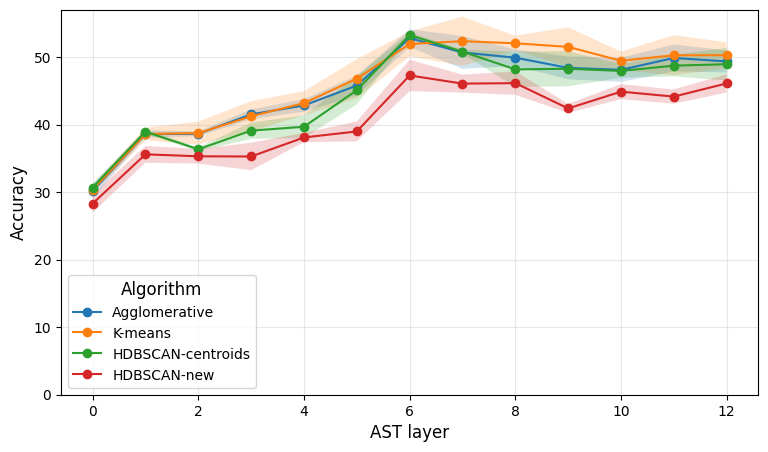

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def results_to_df(results):
    rows = []
    for layer, fams in results.items():
        for fam, d in fams.items():
            rows.append({
                "layer": layer,
                "family": fam,                 # Kmeans / Agglomerative / HDBSCAN
                "mean": float(d["mean"]),
                "std": float(d["std"]),
                "method": d.get("method"),     # None / PCA / Umap / t-SNE (winner for that layer)
                "hyperparams": d.get("hyperparams")
            })
    return pd.DataFrame(rows)

df = results_to_df(best_results).sort_values("layer")

fig, ax = plt.subplots(figsize=(9,5))

for fam in ["Agglomerative", "K-means", "HDBSCAN-centroids", "HDBSCAN-new"]:
    sub = df[df["family"] == fam].sort_values("layer")
    if sub.empty: 
        continue
    x = sub["layer"].values
    y = sub["mean"].values
    s = sub["std"].values

    ax.plot(x, y, marker="o", label=fam)
    ax.fill_between(x, y - s, y + s, alpha=0.2)

ax.set_xlabel("AST layer")
ax.set_ylabel("Accuracy")
ax.legend(title="Algorithm")
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 57)
plt.savefig("/figures/layers_cluters_all_algs_with_raw_grid.pdf")

plt.show()


### dr + clustering


In [26]:
def get_df_reductions(base_path, layer, algorithm_red):
    path = os.path.join(base_path, f"df_layer{layer}_best_results_10.csv")
    df = pd.read_csv(path, header = [0], index_col=0)[:-1]
    df = df[["None", "t-SNE", "PCA", "UMAP"]]
    for index, row in df.iterrows():
        values = row.values
        values = [float(val.split(" ")[0]) for val in values]
        i = np.argmax(values)
        algorithm_red[index].append(reductions[i])
    return algorithm_red

In [ ]:
algorithm_red = {"KMeans": [], "Agglomerative": [], "HDBSCAN": [], "old HDBSCAN":[]}
algorithm_red= get_df_reductions(base_path= "", layer= -100, algorithm_red = algorithm_red)
print(algorithm_red)
algorithm_red= get_df_reductions(base_path= "", layer= -100, algorithm_red = algorithm_red)
print(algorithm_red)
algorithm_red= get_df_reductions(base_path= "", layer= -100, algorithm_red = algorithm_red)
print(algorithm_red)

In [ ]:
reductions = ["None", "t-SNE", "PCA", "UMAP"]
base_path = ""
for i in range(1,13):
    layer = i - 13
    path = os.path.join(base_path, f"df_layer{layer}_best_results.csv")
    df = pd.read_csv(path, header = [0], index_col=0)
    df = df[["None", "t-SNE", "PCA", "UMAP"]]
    for index, row in df.iterrows():
        values = row.values
        values = [float(val.split(" ")[0]) for val in values]
        i = np.argmax(values)
        algorithm_red[index].append(reductions[i])
algorithm_red["K-means"] = algorithm_red.pop("KMeans")
algorithm_red["HDBSCAN-centroids"] = algorithm_red.pop("HDBSCAN")
algorithm_red["HDBSCAN-new"] = algorithm_red.pop("old HDBSCAN")

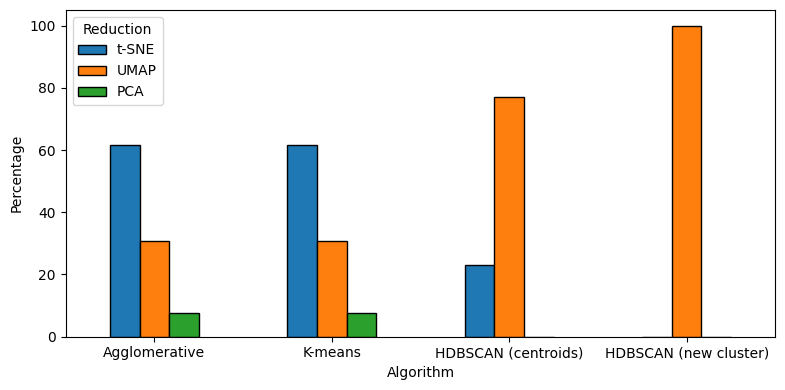

In [ ]:
df = pd.DataFrame({k: pd.Series(v) for k, v in algorithm_red.items()})
counts = {}
for alg, vals in algorithm_red.items():
    counts[alg] = pd.Series(vals).value_counts().reindex(['t-SNE', 'UMAP', 'PCA'], fill_value=0)

df_counts = pd.DataFrame(counts).T  # transpose for easier plotting
df_counts_normalised = df_counts.apply(lambda x: x / 13 * 100 )
# Plot
ax = df_counts_normalised .plot(kind='bar', figsize=(8, 4), edgecolor='black')
plt.xlabel("Algorithm")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Reduction", loc="upper left")
plt.tight_layout()
plt.savefig("figures/histogram_reductions_w_raw.pdf")
plt.show()